In [42]:
./batch_LiCSBAS.sh
python3 -c "from lics_tstools import *; correct_cum_from_tifs('TS_GEOCml10/cum_filt.h5', 'GEOC.EPOCHS', 'tide.geo.azi.tif', 1000, sbovl=True)"
python3 -c "from lics_tstools import *; correct_cum_from_tifs('TS_GEOCml10/cum_filt.h5', 'GEOC.EPOCHS', 'geo.iono.code.sTECA.tif', 14000, sbovl=True)"
python3 -c "from lics_tstools import *; correct_cum_from_tifs('TS_GEOCml10/cum.h5', 'GEOC.EPOCHS', 'tide.geo.azi.tif', 1000, directcorrect = False, sbovl=True)"
python3 -c "from lics_tstools import *; correct_cum_from_tifs('TS_GEOCml10/cum.h5', 'GEOC.EPOCHS', 'geo.iono.code.sTECA.tif', 14000, directcorrect = False, sbovl=True)"


SyntaxError: invalid syntax (3196175566.py, line 1)

In [43]:
from lics_unwrap import *
import re, os, glob
from scipy.constants import speed_of_light
import xarray as xr
def grep1line(arg,filename):
    file = open(filename, "r")
    res=''
    for line in file:
        if re.search(arg, line):
            res=line
            break
    file.close()
    if res:
        res = res.split('\n')[0]
    return res

def load_licsbas_cumh5_as_xrda(cumfile):
    ''' Loads cum.h5 (now only cum layer) as standard xr.DataArray (in lon/lat)'''
    # print(cumfile)
    cum = xr.load_dataset(cumfile) #, engine='h5netcdf')  # or 'netcdf4'
    #
    sizex = len(cum.vel[0])
    sizey = len(cum.vel)
    #
    lon = cum.corner_lon.values + cum.post_lon.values * np.arange(sizex) - 0.5 * float(cum.post_lon)
    lat = cum.corner_lat.values + cum.post_lat.values * np.arange(sizey) + 0.5 * float(cum.post_lat)  # maybe needed? yes! for gridline/AREA that is default in rasterio...
    #
    time = np.array(([dt.datetime.strptime(str(imd), '%Y%m%d') for imd in cum.imdates.values]))
    #
    velxr = xr.DataArray(cum.vel.values.reshape(sizey, sizex), coords=[lat, lon], dims=["lat", "lon"])
    # LiCSBAS uses 0 instead of nans...
    velxr = velxr.where(velxr != 0)
    velxr.attrs['unit'] = 'mm/year'
    # vinterceptxr = xr.DataArray(cum.vintercept.values.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
    #
    cumxr = xr.DataArray(cum.cum.values, coords=[time, lat, lon], dims=["time", "lat", "lon"])
    cumxr.attrs['unit'] = 'mm'
    refarea = str(cum.refarea.values)
    # x is first...
    refx1 = int(refarea.split('/')[0].split(':')[0])
    refx2 = int(refarea.split('/')[0].split(':')[1])
    refy1 = int(refarea.split('/')[1].split(':')[0])
    refy2 = int(refarea.split('/')[1].split(':')[1])
    refx=int((refx2+refx1)/2)
    refy = int((refy2 + refy1) / 2)
    cumxr.attrs['ref_lon'] = cumxr.lon.values[refx]
    cumxr.attrs['ref_lat'] = cumxr.lat.values[refy]
    return cumxr


def correct_cum_from_tifs(cumhdfile, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.tif', tif_scale2mm = 1, sbovl=False ,outputhdf = None, directcorrect = True, newcumname = 'external_data'):
    ''' This will load the cum.h5 and either correct cum layer (if directcorrect==True) or add new data var to the cube (if not directcorrect)

    Args:
        cumhdfile (str): input cum.h5 file
        tifdir (str): where to find corrections. Must be in epoch subdirs, e.g. tifdir/20240216/20240216.ext
        ext (str):    what extension is used for the correction files after the epochdate, e.g. 'geo.iono.code.tif', 'tide.geo.tif'
        tif_scale2mm (float):  for iono [rad]: 55.465/(4*np.pi), for SET [m]: 1000, for sltd [rad] same as iono but opposite sign (real delay)
        outputhdf (str):   if None, will overwrite the input file, otherwise will export to this filename (functional: H5, NC, possibly: zarr)
        directcorrect (bool): if True, it will directly reduce the cum data, otherwise it stores it to the datacube
    
    Returns:
        bool:  True if all went ok
    '''
    if not outputhdf:
        outputhdf = cumhdfile
    print('loading LiCSBAS datacube')
    print('you are running hacked correct_cum script. (MN)')
    cumxr = load_licsbas_cumh5_as_xrda(cumhdfile)
    print('loading external corrections')
    if 'STEC' in ext.upper():
        cumxr = cumcube_sbovl_remove_from_tifs(cumxr, tifdir, ext, tif_scale2mm, only_load_ext = not directcorrect)
    else:
        cumxr = cumcube_remove_from_tifs(cumxr, tifdir=tifdir, ext=ext, tif_scale2mm=tif_scale2mm, sbovl=sbovl, only_load_ext=not directcorrect)
    if type(cumxr) == type(False):
        print('ERROR - probably the correction did not exist for some epochs. Cancelling')
        return False
    cumh = xr.load_dataset(cumhdfile)
    if directcorrect:
        print('directly corrected')
        breakpoint()
        cumh.cum.values = cumh.cum.values - cumxr.values
    else:
        codes = ['iono', 'tide', 'icams', 'sltd']
        for c in codes:
            if ext.find(c)>-1:
                newcumname = c
        if newcumname in cumh:
            # rename to extension
            newcumname = ext
        if newcumname in cumh:
            print('WARNING, the layer "'+newcumname+'"already existed in the datacube! Will overwrite it now')
        print('storing as variable: '+newcumname)
        cumh[newcumname]=cumh.cum.copy()
        cumh[newcumname].values=cumxr.values
    print('saving to: '+outputhdf)
    cumh.to_netcdf(outputhdf)
    return True


# looks a bit complex so I will create for sbovl specifically
def cumcube_sbovl_remove_from_tifs(cumxr, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.sTECA.tif', tif_scale2mm = 14000, only_load_ext = False):
    ''' Correct directly from tifs, no need to store in cubes.
    NOTE - you can also just load the exts into the cumcube without removing anything..
    (in any case, values are referred temporally to the first epoch)
    
    Args:
        cumxr (xr.DataArray): only cum
        tifdir:
        ext1: sTECA
        ext2: sTECB
        tif_scale2mm:  for iono [rad]: 14000 for sTECA/B
        only_load_ext:  would only load the ext files in the cube and return it (no removal!)
        
    Returns:
        xr.DataArray: corrected cum values (only_load_ext=False) or only loaded corrections
    '''
    #if check_complete_set(cumxr.time.values)
    #times = cumxr.time.values
    reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
    #
    print('sbovl activated')
    firstepvals = 0
    leneps = len(cumxr)
    error_log = []
    for i in range(leneps): # times first coord..
        print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
        cumepoch = cumxr[i]
        epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
        if 'STEC' in ext.upper():
            ext1='geo.iono.code.sTECA.tif'
            ext2='geo.iono.code.sTECB.tif'
        extif1 = os.path.join(tifdir, epoch, epoch+'.'+ext1)
        extif2 = os.path.join(tifdir, epoch, epoch+'.'+ext2)
        if not os.path.exists(extif1) or not os.path.exists(extif2):
            extif1 = os.path.join(tifdir, epoch+'.'+ext1)
            extif2 = os.path.join(tifdir, epoch+'.'+ext2)
        
        try:
            if not os.path.exists(extif1) or not os.path.exists(extif2):
                raise FileNotFoundError(f'File not found: {extif1} or {extif2}')
            #backward
            extepoch1 = load_tif2xr(extif1)
            extepoch1 = extepoch1.where(extepoch1 != 0) # just in case...
            extepoch1 = extepoch1.interp_like(cumepoch, method='linear') # CHECK! ##looks redundant so far (maybe not)
            #forward
            extepoch2 = load_tif2xr(extif2)
            extepoch2 = extepoch2.where(extepoch2 != 0)
            extepoch2 = extepoch2.interp_like(cumepoch, method='linear')
            
            ####gradient method Lazecky et al. 2023,GRL #https://github.com/comet-licsar/daz/blob/main/lib/daz_iono.py#L561
            ###parameter for TEC gradient
            azpix=14000
            PRF = 486.486
            k = 40.308193 # m^3 / s^2
            f0 = 5.4050005e9
            c = speed_of_light
        
            ##scaling_tif
            workdir=os.getcwd()
            frame=os.path.basename(workdir)
            metafolder = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
            # Check if the metadata folder exists
            if os.path.exists(metafolder) and os.path.isdir(metafolder):
                scaling_tif = None  # Initialize variable to track if a file is found
                
                for files in os.listdir(metafolder):  
                    if files.endswith('bovl_scaling.tif'):
                        scaling_tif = os.path.join(metafolder, files)
                     
                # Check if no scaling file was found
                if scaling_tif is None:
                    raise FileNotFoundError("No .geo.sbovl_scaling.tif file found in metadata folder.")
            else:
                raise FileNotFoundError("metadata is not exist in LiCSAR_public")    

            ##scaling2dfdc
            scaling_factor=load_tif2xr(scaling_tif)
            scaling_factor = scaling_factor.interp_like(cumepoch, method='linear')
            dfDC=azpix*PRF/(2*np.pi*scaling_factor)
            fH = f0 + dfDC*0.5
            fL = f0 - dfDC*0.5
            tecovl=(extepoch1/fH-extepoch2/fL)
            iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
            iono_grad_mm=iono_grad*azpix #mm
            
        except Exception as e:
            print(f'\n\r WARNING: failed to load or compute correction for epoch {epoch}: {str(e)}')
            error_log.append(epoch)
            iono_grad_mm = cumepoch.copy() * np.nan
            iono_grad_mm.attrs.clear()
        
        ##TODO check this useful for sbovl or not? We are using absolute so skip that! 
        ref_value = iono_grad_mm.sel(lon=reflon, lat=reflat, method='nearest')
        # If ref_value is NaN, replace it with 0
        if np.isnan(ref_value.values):
            ref_value = 0  # Assign zero to avoid NaN propagation
        else:
            ref_value = ref_value.values  # Extract actual value

        # Apply reference correction
        iono_grad_mm = iono_grad_mm - ref_value
        
        # ##fill na with 0
        # iono_grad_mm=iono_grad_mm.fillna(0)
                
        if i == 0:
            firstepvals = iono_grad_mm.fillna(0).values
        # here we do diff w.r.t. first epoch
        iono_grad_mm.values = iono_grad_mm.values - firstepvals
        
        if only_load_ext:
            cumxr.values[i] = iono_grad_mm.values
        else:
            cumxr.values[i] = cumxr.values[i] - iono_grad_mm.values
    print('\n\r  done')
    
    # Save the list of failed epochs
    if error_log:
        with open(f"failed_{ext}.txt", "w") as f:
            for epoch in error_log:
                f.write(epoch + "\n")
        print(f"\nSaved list of failed epochs to failed_{ext}.txt")
    return cumxr

# def check_complete_set(imdates, epochsdir, ext='geo.iono.code.tif')
def cumcube_remove_from_tifs(cumxr, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.tif', sbovl=False,tif_scale2mm = 1, only_load_ext = False):
    ''' Correct directly from tifs, no need to store in cubes.
    NOTE - you can also just load the exts into the cumcube without removing anything..
    (in any case, values are referred temporally to the first epoch)
    
    Args:
        cumxr (xr.DataArray): only cum
        tifdir:
        ext:
        tif_scale2mm:  for iono [rad]: (0.055465*1000)/(4*np.pi), for SET [m]: 1/1000
        only_load_ext:  would only load the ext files in the cube and return it (no removal!)
        
    Returns:
        xr.DataArray: corrected cum values (only_load_ext=False) or only loaded corrections
    '''
    #if check_complete_set(cumxr.time.values)
    #times = cumxr.time.values
    reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
    #
    firstepvals = 0
    leneps = len(cumxr)
    error_log = [] ##to save/remove/recreate for second iteration
    
    for i in range(leneps): # times first coord..
        print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
        cumepoch = cumxr[i]
        epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
        extif = os.path.join(tifdir, epoch, epoch+'.'+ext)
        if not os.path.exists(extif):
            extif = os.path.join(tifdir, epoch + '.' + ext)
        
        try:
            if not os.path.exists(extif):
                raise FileNotFoundError(f'File not found: {extif}')
            extepoch = load_tif2xr(extif)
            extepoch = extepoch.where(extepoch != 0) # just in case...
            extepoch = extepoch * tif_scale2mm
            extepoch = extepoch.interp_like(cumepoch, method='linear') # CHECK!
            # if not sbovl_abs:
                # reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
            extepoch = extepoch - extepoch.sel(lon=reflon, lat=reflat, method='nearest') # could be done better though
        except Exception as e:
            print(f'\n\r WARNING: failed to load correction for epoch {epoch}: {str(e)}')
            error_log.append(extif)
            extepoch = cumepoch.copy() * np.nan
            extepoch.attrs.clear()    
            
            
        if i == 0:
            firstepvals = extepoch.fillna(0).values
        # here we do diff w.r.t. first epoch
        extepoch.values = extepoch.values - firstepvals
        # mask that - not needed (?)
        #extepoch = extepoch.where(~np.isnan(cumxr[i]))
        if only_load_ext:
            cumxr.values[i] = extepoch.values
        else:
            cumxr.values[i] = cumxr.values[i] - extepoch.values
    print('\n\r  done')
    
    # Save the list of failed paths
    if error_log:
        with open(f"failed_{ext}.txt", "w") as f:
            for path in error_log:
                f.write(path + "\n")
        print(f"\nSaved list of corrupted or missing files to corrupted_ext_tifs.txt")

    #if only_load_ext:
    #    cumxr = cumxr-cumxr[0] #.cumsum(axis=0)
    #    cumxr = cumxr.cumsum(axis=0)-cumxr[0]
    return cumxr

In [58]:
study_folder='/work/scratch-pw2/licsar/mnergiz/remove_me_please/remove/021D_05266_252525'
tifdir=os.path.join(study_folder, 'GEOC.EPOCHS')
# correct_cum_from_tifs(os.path.join(study_folder, 'TS_GEOCml10/cum_filt.h5'), os.path.join(study_folder, 'GEOC.EPOCHS'), 'tide.geo.azi.tif', 1000, sbovl=True)

In [44]:
# correct_cum_from_tifs(cumhdfile, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.tif', tif_scale2mm = 1, sbovl=False ,outputhdf = None, directcorrect = True, newcumname = 'external_data'):
cumhdfile=os.path.join(study_folder, 'TS_GEOCml10/cum.h5')
# cumxr = load_licsbas_cumh5_as_xrda(cumhdfile)
# print('loading external corrections')
# if 'STEC' in ext.upper():
#     cumxr = cumcube_sbovl_remove_from_tifs(cumxr, tifdir, ext, tif_scale2mm, only_load_ext = not directcorrect)
# else:
#     cumxr = cumcube_remove_from_tifs(cumxr, tifdir=tifdir, ext=ext, tif_scale2mm=tif_scale2mm, sbovl=sbovl, only_load_ext=not directcorrect)
# if type(cumxr) == type(False):
#     print('ERROR - probably the correction did not exist for some epochs. Cancelling')
#     return False
# cumh = xr.load_dataset(cumhdfile)
# if directcorrect:
#     print('directly corrected')
#     breakpoint()
#     cumh.cum.values = cumh.cum.values - cumxr.values
# else:
#     codes = ['iono', 'tide', 'icams', 'sltd']
#     for c in codes:
#         if ext.find(c)>-1:
#             newcumname = c
#     if newcumname in cumh:
#         # rename to extension
#         newcumname = ext
#     if newcumname in cumh:
#         print('WARNING, the layer "'+newcumname+'"already existed in the datacube! Will overwrite it now')
#     print('storing as variable: '+newcumname)
#     cumh[newcumname]=cumh.cum.copy()
#     cumh[newcumname].values=cumxr.values
# print('saving to: '+outputhdf)
# cumh.to_netcdf(outputhdf)
# return True



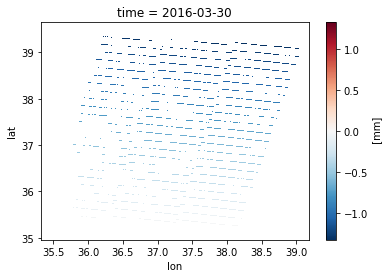

In [11]:
cumxr[3].plot()

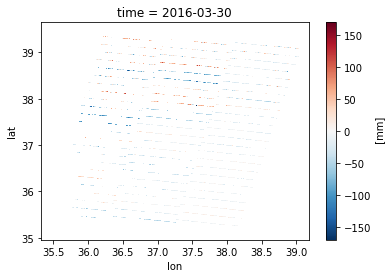

In [13]:
cumxr[3].plot()

In [39]:
cumh5 = h5.File(cumhdfile,'r')  ##open cum.h5 to read non-filtered data

In [45]:
 # looks a bit complex so I will create for sbovl specifically
def cumcube_sbovl_remove_from_tifs(cumxr, tifdir = 'GEOC.EPOCHS', ext='geo.iono.code.sTECA.tif', tif_scale2mm = 14000, only_load_ext = False):
    ''' Correct directly from tifs, no need to store in cubes.
    NOTE - you can also just load the exts into the cumcube without removing anything..
    (in any case, values are referred temporally to the first epoch)
    
    Args:
        cumxr (xr.DataArray): only cum
        tifdir:
        ext1: sTECA
        ext2: sTECB
        tif_scale2mm:  for iono [rad]: 14000 for sTECA/B
        only_load_ext:  would only load the ext files in the cube and return it (no removal!)
        
    Returns:
        xr.DataArray: corrected cum values (only_load_ext=False) or only loaded corrections
    '''
    #if check_complete_set(cumxr.time.values)
    #times = cumxr.time.values
    reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
    #
    print('sbovl activated')
    firstepvals = 0
    leneps = len(cumxr)
    error_log = []
    for i in range(leneps): # times first coord..
        print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
        cumepoch = cumxr[i]
        epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
        if 'STEC' in ext.upper():
            ext1='geo.iono.code.sTECA.tif'
            ext2='geo.iono.code.sTECB.tif'
        extif1 = os.path.join(tifdir, epoch, epoch+'.'+ext1)
        extif2 = os.path.join(tifdir, epoch, epoch+'.'+ext2)
        if not os.path.exists(extif1) or not os.path.exists(extif2):
            extif1 = os.path.join(tifdir, epoch+'.'+ext1)
            extif2 = os.path.join(tifdir, epoch+'.'+ext2)
        
        try:
            if not os.path.exists(extif1) or not os.path.exists(extif2):
                raise FileNotFoundError(f'File not found: {extif1} or {extif2}')
            #backward
            extepoch1 = load_tif2xr(extif1)
            extepoch1 = extepoch1.where(extepoch1 != 0) # just in case...
            extepoch1 = extepoch1.interp_like(cumepoch, method='linear') # CHECK! ##looks redundant so far (maybe not)
            #forward
            extepoch2 = load_tif2xr(extif2)
            extepoch2 = extepoch2.where(extepoch2 != 0)
            extepoch2 = extepoch2.interp_like(cumepoch, method='linear')
            
            ####gradient method Lazecky et al. 2023,GRL #https://github.com/comet-licsar/daz/blob/main/lib/daz_iono.py#L561
            ###parameter for TEC gradient
            azpix=14000
            PRF = 486.486
            k = 40.308193 # m^3 / s^2
            f0 = 5.4050005e9
            c = speed_of_light
        
            ##scaling_tif
            workdir=os.getcwd()
            frame=os.path.basename(workdir)
            metafolder = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
            # Check if the metadata folder exists
            if os.path.exists(metafolder) and os.path.isdir(metafolder):
                scaling_tif = None  # Initialize variable to track if a file is found
                
                for files in os.listdir(metafolder):  
                    if files.endswith('bovl_scaling.tif'):
                        scaling_tif = os.path.join(metafolder, files)
                     
                # Check if no scaling file was found
                if scaling_tif is None:
                    raise FileNotFoundError("No .geo.sbovl_scaling.tif file found in metadata folder.")
            else:
                raise FileNotFoundError("metadata is not exist in LiCSAR_public")    

            ##scaling2dfdc
            scaling_factor=load_tif2xr(scaling_tif)
            scaling_factor = scaling_factor.interp_like(cumepoch, method='linear')
            dfDC=azpix*PRF/(2*np.pi*scaling_factor)
            fH = f0 + dfDC*0.5
            fL = f0 - dfDC*0.5
            tecovl=(extepoch1/fH-extepoch2/fL)
            iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
            iono_grad_mm=iono_grad*azpix #mm
            
        except Exception as e:
            print(f'\n\r WARNING: failed to load or compute correction for epoch {epoch}: {str(e)}')
            error_log.append(epoch)
            iono_grad_mm = cumepoch.copy() * np.nan
            iono_grad_mm.attrs.clear()
        
        ##TODO check this useful for sbovl or not? We are using absolute so skip that! 
        ref_value = iono_grad_mm.sel(lon=reflon, lat=reflat, method='nearest')
        # If ref_value is NaN, replace it with 0
        if np.isnan(ref_value.values):
            ref_value = 0  # Assign zero to avoid NaN propagation
        else:
            ref_value = ref_value.values  # Extract actual value

        # Apply reference correction
        iono_grad_mm = iono_grad_mm - ref_value
        
        # ##fill na with 0
        # iono_grad_mm=iono_grad_mm.fillna(0)
                
        if i == 0:
            firstepvals = iono_grad_mm.fillna(0).values
        # here we do diff w.r.t. first epoch
        iono_grad_mm.values = iono_grad_mm.values - firstepvals
        
        if only_load_ext:
            cumxr.values[i] = iono_grad_mm.values
        else:
            cumxr.values[i] = cumxr.values[i] - iono_grad_mm.values
    print('\n\r  done')
    
    # Save the list of failed epochs
    if error_log:
        with open(f"failed_{ext}.txt", "w") as f:
            for epoch in error_log:
                f.write(epoch + "\n")
        print(f"\nSaved list of failed epochs to failed_{ext}.txt")
    return cumxr

In [46]:
reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
#
print('sbovl activated')
firstepvals = 0
leneps = len(cumxr)
error_log = []
# for i in range(leneps): # times first coord..
#     print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
#     cumepoch = cumxr[i]
#     epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
#     if 'STEC' in ext.upper():
#         ext1='geo.iono.code.sTECA.tif'
#         ext2='geo.iono.code.sTECB.tif'
#     extif1 = os.path.join(tifdir, epoch, epoch+'.'+ext1)
#     extif2 = os.path.join(tifdir, epoch, epoch+'.'+ext2)
#     if not os.path.exists(extif1) or not os.path.exists(extif2):
#         extif1 = os.path.join(tifdir, epoch+'.'+ext1)
#         extif2 = os.path.join(tifdir, epoch+'.'+ext2)
    
#     try:
#         if not os.path.exists(extif1) or not os.path.exists(extif2):
#             raise FileNotFoundError(f'File not found: {extif1} or {extif2}')
#         #backward
#         extepoch1 = load_tif2xr(extif1)
#         extepoch1 = extepoch1.where(extepoch1 != 0) # just in case...
#         extepoch1 = extepoch1.interp_like(cumepoch, method='linear') # CHECK! ##looks redundant so far (maybe not)
#         #forward
#         extepoch2 = load_tif2xr(extif2)
#         extepoch2 = extepoch2.where(extepoch2 != 0)
#         extepoch2 = extepoch2.interp_like(cumepoch, method='linear')
        
#         ####gradient method Lazecky et al. 2023,GRL #https://github.com/comet-licsar/daz/blob/main/lib/daz_iono.py#L561
#         ###parameter for TEC gradient
#         azpix=14000
#         PRF = 486.486
#         k = 40.308193 # m^3 / s^2
#         f0 = 5.4050005e9
#         c = speed_of_light
    
#         ##scaling_tif
#         workdir=os.getcwd()
#         frame=os.path.basename(workdir)
#         metafolder = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
#         # Check if the metadata folder exists
#         if os.path.exists(metafolder) and os.path.isdir(metafolder):
#             scaling_tif = None  # Initialize variable to track if a file is found
            
#             for files in os.listdir(metafolder):  
#                 if files.endswith('bovl_scaling.tif'):
#                     scaling_tif = os.path.join(metafolder, files)
                 
#             # Check if no scaling file was found
#             if scaling_tif is None:
#                 raise FileNotFoundError("No .geo.sbovl_scaling.tif file found in metadata folder.")
#         else:
#             raise FileNotFoundError("metadata is not exist in LiCSAR_public")    

#         ##scaling2dfdc
#         scaling_factor=load_tif2xr(scaling_tif)
#         scaling_factor = scaling_factor.interp_like(cumepoch, method='linear')
#         dfDC=azpix*PRF/(2*np.pi*scaling_factor)
#         fH = f0 + dfDC*0.5
#         fL = f0 - dfDC*0.5
#         tecovl=(extepoch1/fH-extepoch2/fL)
#         iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
#         iono_grad_mm=iono_grad*azpix #mm
        
#     except Exception as e:
#         print(f'\n\r WARNING: failed to load or compute correction for epoch {epoch}: {str(e)}')
#         error_log.append(epoch)
#         iono_grad_mm = cumepoch.copy() * np.nan
#         iono_grad_mm.attrs.clear()
    
#     ##TODO check this useful for sbovl or not? We are using absolute so skip that! 
#     ref_value = iono_grad_mm.sel(lon=reflon, lat=reflat, method='nearest')
#     # If ref_value is NaN, replace it with 0
#     if np.isnan(ref_value.values):
#         ref_value = 0  # Assign zero to avoid NaN propagation
#     else:
#         ref_value = ref_value.values  # Extract actual value

#     # Apply reference correction
#     iono_grad_mm = iono_grad_mm - ref_value
    
#     # ##fill na with 0
#     # iono_grad_mm=iono_grad_mm.fillna(0)
            
#     if i == 0:
#         firstepvals = iono_grad_mm.fillna(0).values
#     # here we do diff w.r.t. first epoch
#     iono_grad_mm.values = iono_grad_mm.values - firstepvals
    
#     if only_load_ext:
#         cumxr.values[i] = iono_grad_mm.values
#     else:
#         cumxr.values[i] = cumxr.values[i] - iono_grad_mm.values
# print('\n\r  done')

# # Save the list of failed epochs
# if error_log:
#     with open(f"failed_{ext}.txt", "w") as f:
#         for epoch in error_log:
#             f.write(epoch + "\n")
#     print(f"\nSaved list of failed epochs to failed_{ext}.txt")

sbovl activated


In [47]:
leneps

204

In [48]:
cumepoch = cumxr[4]

In [51]:
cumepoch

<xarray.DataArray (lat: 469, lon: 386)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
    time     datetime64[ns] 2016-04-11
  * lat      (lat) float64 39.64 39.63 39.62 39.61 ... 34.99 34.98 34.97 34.96
  * lon      (lon) float64 35.32 35.33 35.34 35.35 ... 39.14 39.15 39.16 39.17
Attributes:
    unit:     mm
    ref_lon:  38.155
    ref_lat:  35.2616666

In [59]:
tifdir

'/work/scratch-pw2/licsar/mnergiz/remove_me_please/remove/021D_05266_252525/GEOC.EPOCHS'

In [60]:
cumepoch

<xarray.DataArray (lat: 469, lon: 386)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
    time     datetime64[ns] 2016-04-11
  * lat      (lat) float64 39.64 39.63 39.62 39.61 ... 34.99 34.98 34.97 34.96
  * lon      (lon) float64 35.32 35.33 35.34 35.35 ... 39.14 39.15 39.16 39.17
Attributes:
    unit:     mm
    ref_lon:  38.155
    ref_lat:  35.2616666

In [64]:
epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
ext='geo.iono.code.sTECA.tif'
if 'STEC' in ext.upper():
    ext1='geo.iono.code.sTECA.tif'
    ext2='geo.iono.code.sTECB.tif'
extif1 = os.path.join(tifdir, epoch, epoch+'.'+ext1)
extif2 = os.path.join(tifdir, epoch, epoch+'.'+ext2)
if not os.path.exists(extif1) or not os.path.exists(extif2):
    extif1 = os.path.join(tifdir, epoch+'.'+ext1)
    extif2 = os.path.join(tifdir, epoch+'.'+ext2)


In [74]:
if not os.path.exists(extif1) or not os.path.exists(extif2):
    raise FileNotFoundError(f'File not found: {extif1} or {extif2}')
#backward
extepoch1 = load_tif2xr(extif1)
extepoch1 = extepoch1.where(extepoch1 != 0) # just in case...
extepoch1 = extepoch1.interp_like(cumepoch, method='linear') # CHECK! ##looks redundant so far (maybe not)
#forward
extepoch2 = load_tif2xr(extif2)
extepoch2 = extepoch2.where(extepoch2 != 0)
extepoch2 = extepoch2.interp_like(cumepoch, method='linear')

####gradient method Lazecky et al. 2023,GRL #https://github.com/comet-licsar/daz/blob/main/lib/daz_iono.py#L561
###parameter for TEC gradient
azpix=14000
PRF = 486.486
k = 40.308193 # m^3 / s^2
f0 = 5.4050005e9
c = speed_of_light


In [76]:
##scaling_tif
workdir=study_folder
frame=os.path.basename(study_folder)
metafolder = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
# Check if the metadata folder exists
if os.path.exists(metafolder) and os.path.isdir(metafolder):
    scaling_tif = None  # Initialize variable to track if a file is found
    
    for files in os.listdir(metafolder):  
        if files.endswith('bovl_scaling.tif'):
            scaling_tif = os.path.join(metafolder, files)
         
    # Check if no scaling file was found
    if scaling_tif is None:
        raise FileNotFoundError("No .geo.sbovl_scaling.tif file found in metadata folder.")
else:
    raise FileNotFoundError("metadata is not exist in LiCSAR_public")    

In [93]:
##scaling2dfdc
scaling_factor=load_tif2xr(scaling_tif)
scaling_factor = scaling_factor.interp_like(cumepoch, method='linear')
# export_xr2tif(scaling_factor, 'scaled_intered.tif')
# dfDC=azpix*PRF/(2*np.pi*scaling_factor)
dfDC=4350
fH = f0 + dfDC*0.5
fL = f0 - dfDC*0.5
tecovl=(extepoch1/fH-extepoch2/fL)
iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
iono_grad_mm=iono_grad*azpix #mm

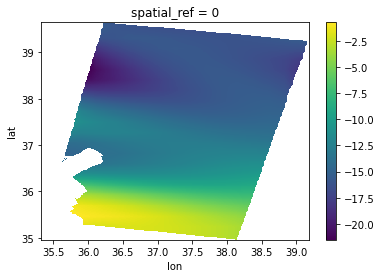

In [95]:
iono_grad_mm.plot()

In [72]:
extepoch1

<xarray.DataArray (lat: 4694, lon: 3867)>
[18151698 values with dtype=float32]
Coordinates:
  * lon          (lon) float64 35.33 35.33 35.33 35.33 ... 39.19 39.19 39.2
  * lat          (lat) float64 39.65 39.65 39.64 39.64 ... 34.96 34.95 34.95
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [66]:

#     try:
#         if not os.path.exists(extif1) or not os.path.exists(extif2):
#             raise FileNotFoundError(f'File not found: {extif1} or {extif2}')
#         #backward
#         extepoch1 = load_tif2xr(extif1)
#         extepoch1 = extepoch1.where(extepoch1 != 0) # just in case...
#         extepoch1 = extepoch1.interp_like(cumepoch, method='linear') # CHECK! ##looks redundant so far (maybe not)
#         #forward
#         extepoch2 = load_tif2xr(extif2)
#         extepoch2 = extepoch2.where(extepoch2 != 0)
#         extepoch2 = extepoch2.interp_like(cumepoch, method='linear')
        
#         ####gradient method Lazecky et al. 2023,GRL #https://github.com/comet-licsar/daz/blob/main/lib/daz_iono.py#L561
#         ###parameter for TEC gradient
#         azpix=14000
#         PRF = 486.486
#         k = 40.308193 # m^3 / s^2
#         f0 = 5.4050005e9
#         c = speed_of_light
    
#         ##scaling_tif
#         workdir=os.getcwd()
#         frame=os.path.basename(workdir)
#         metafolder = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
#         # Check if the metadata folder exists
#         if os.path.exists(metafolder) and os.path.isdir(metafolder):
#             scaling_tif = None  # Initialize variable to track if a file is found
            
#             for files in os.listdir(metafolder):  
#                 if files.endswith('bovl_scaling.tif'):
#                     scaling_tif = os.path.join(metafolder, files)
                 
#             # Check if no scaling file was found
#             if scaling_tif is None:
#                 raise FileNotFoundError("No .geo.sbovl_scaling.tif file found in metadata folder.")
#         else:
#             raise FileNotFoundError("metadata is not exist in LiCSAR_public")    

#         ##scaling2dfdc
#         scaling_factor=load_tif2xr(scaling_tif)
#         scaling_factor = scaling_factor.interp_like(cumepoch, method='linear')
#         dfDC=azpix*PRF/(2*np.pi*scaling_factor)
#         fH = f0 + dfDC*0.5
#         fL = f0 - dfDC*0.5
#         tecovl=(extepoch1/fH-extepoch2/fL)
#         iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
#         iono_grad_mm=iono_grad*azpix #mm
        
#     except Exception as e:
#         print(f'\n\r WARNING: failed to load or compute correction for epoch {epoch}: {str(e)}')
#         error_log.append(epoch)
#         iono_grad_mm = cumepoch.copy() * np.nan
#         iono_grad_mm.attrs.clear()
    
#     ##TODO check this useful for sbovl or not? We are using absolute so skip that! 
#     ref_value = iono_grad_mm.sel(lon=reflon, lat=reflat, method='nearest')
#     # If ref_value is NaN, replace it with 0
#     if np.isnan(ref_value.values):
#         ref_value = 0  # Assign zero to avoid NaN propagation
#     else:
#         ref_value = ref_value.values  # Extract actual value

#     # Apply reference correction
#     iono_grad_mm = iono_grad_mm - ref_value
    
#     # ##fill na with 0
#     # iono_grad_mm=iono_grad_mm.fillna(0)
            
#     if i == 0:
#         firstepvals = iono_grad_mm.fillna(0).values
#     # here we do diff w.r.t. first epoch
#     iono_grad_mm.values = iono_grad_mm.values - firstepvals
    
#     if only_load_ext:
#         cumxr.values[i] = iono_grad_mm.values
#     else:
#         cumxr.values[i] = cumxr.values[i] - iono_grad_mm.values
# print('\n\r  done')

# # Save the list of failed epochs
# if error_log:
#     with open(f"failed_{ext}.txt", "w") as f:
#         for epoch in error_log:
#             f.write(epoch + "\n")
#     print(f"\nSaved list of failed epochs to failed_{ext}.txt")